In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
merged_path = repository.download_dataset(
    name="kang_29K_ctrl-ifnb_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = str(Path(analysis_directory.name) / "counts.zarr")
repack_store(
    f"{merged_path}/data.zarr",
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=str(Path(analysis_directory.name) / "condition_analysis.zarr"),
    default_assay="RNA",
    nthreads=4,
)

Downloading bucket files: 97971591 / 97971591 complete

Downloading bytes: 97971591 / 97971591 complete

Repacking RNA/artifacts/normalized//data: 2 / 2 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

...

Repacking RNA/artifacts/neighbors//distances: 1 / 1 complete

Repacking RNA/artifacts/embedding_initialization//cluster_centers: 1 / 1 complete

Repacking RNA/counts: 3 / 3 complete

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  RNA/counts: shape=(18598, 35635), dtype=uint32, chunks=(7015, 3360), shards=(7015, 36960)


In [2]:
import numpy as np

sample_id = np.asarray(ds.cells.fetch_all("sample_id")).astype(str)
values, counts = np.unique(sample_id, return_counts=True)
print(dict(zip(values.tolist(), counts.tolist())))

{'ctrl': 8487, 'stim': 10111}


In [3]:
isg15 = ds.run_statistical_testing(
    "ISG15",
    group_by="sample_id",
    test="welch",
)
isg15.tables["ISG15"]

/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/scarf/scarf/datastore/_operations/features.py:3218: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


,group_1,group_2,n_1,n_2,t_statistic,df,mean_1,mean_2,mean_difference,p_value,p_value_adjusted
0,stim,ctrl,10111,8486,92.615877,10238.679377,20.423142,0.361885,20.061257,0.0,0.0


In [4]:
loaded = ds.get_statistical_tests(
    group_key="sample_id",
    method="welch",
    keys="ISG15",
)
loaded.tables["ISG15"]

,group_1,group_2,n_1,n_2,t_statistic,df,mean_1,mean_2,mean_difference,p_value,p_value_adjusted
0,stim,ctrl,10111,8486,92.615877,10238.679377,20.423142,0.361885,20.061257,0.0,0.0


In [5]:
isg15_greater = ds.run_statistical_testing(
    "ISG15",
    group_by="sample_id",
    test="welch",
    alternative="greater",
)
loaded_greater = ds.get_statistical_tests(
    group_key="sample_id",
    method="welch",
    keys="ISG15",
    alternative="greater",
)
print(
    "two-sided p:",
    float(isg15.tables["ISG15"]["p_value"].iloc[0]),
)
print(
    "greater    p:",
    float(loaded_greater.tables["ISG15"]["p_value"].iloc[0]),
)

/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/scarf/scarf/datastore/_operations/features.py:3218: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


two-sided p: 0.0
greater    p: 0.0


In [6]:
import pandas as pd

panel = ["ISG15", "IFIT1", "MX1", "CD3D", "LYZ"]
panel_result = ds.run_statistical_testing(
    panel,
    group_by="sample_id",
    test="welch",
)
pd.concat(
    {gene: panel_result.tables[gene] for gene in panel},
    names=["gene"],
).reset_index(level="gene")[
    ["gene", "mean_1", "mean_2", "mean_difference", "p_value", "p_value_adjusted"]
]

/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/scarf/scarf/datastore/_operations/features.py:3218: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/scarf/scarf/datastore/_operations/features.py:3218: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/scarf/scarf/datastore/_operations/features.py:3218: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/scarf/scarf/datastore/_operations/features.py:3218: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/scarf/scarf/datastore/_operations/features.py:3218: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


,gene,mean_1,mean_2,mean_difference,p_value,p_value_adjusted
0,ISG15,20.423142,0.361885,20.061257,0.000000e+00,0.000000e+00
0,IFIT1,2.438845,0.025750,2.413095,0.000000e+00,0.000000e+00
0,MX1,1.710421,0.068298,1.642123,0.000000e+00,0.000000e+00
0,CD3D,0.404702,0.475677,-0.070975,6.010878e-10,7.513598e-10
0,LYZ,0.795705,1.014291,-0.218586,1.253155e-09,1.253155e-09


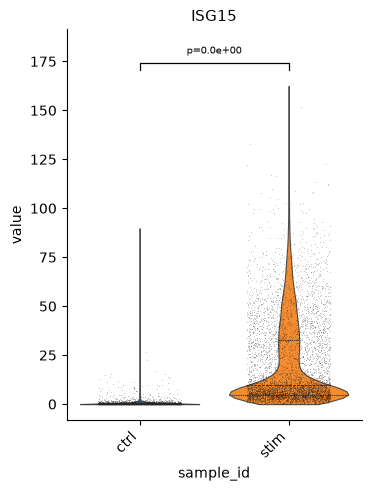

In [7]:
ds.plots.distribution(
    "ISG15",
    group_by="sample_id",
    kind="violin",
    stats_results=isg15,
)

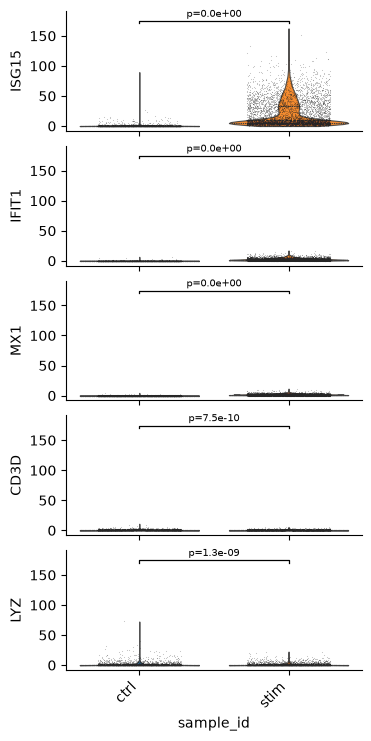

In [8]:
ds.plots.distribution(
    panel,
    group_by="sample_id",
    kind="stacked_violin",
    share_y=True,
    stats_results=panel_result,
)

In [9]:
isg15_mw = ds.run_statistical_testing(
    "ISG15",
    group_by="sample_id",
    test="mann_whitney",
)
isg15_mw.tables["ISG15"]

/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/scarf/scarf/datastore/_operations/features.py:3218: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


,group_1,group_2,n_1,n_2,u_statistic,mean_1,mean_2,mean_difference,p_value,p_value_adjusted
0,stim,ctrl,10111,8486,84637143.5,20.423142,0.361885,20.061257,0.0,0.0


In [10]:
cluster_result = ds.run_statistical_testing(
    ["ISG15"],
    group_by="RNA_clusters",
    test="kruskal_wallis",
    posthoc="dunn",
)
print("omnibus:", cluster_result.tables["ISG15"].to_dict("records"))
print("pairwise rows:", len(cluster_result.posthoc_tables["ISG15"]))
cluster_result.posthoc_tables["ISG15"].head()

omnibus: [{'kruskal_statistic': 15277.613419282381, 'df': 19, 'p_value': 0.0, 'p_value_adjusted': 0.0}]
pairwise rows: 190


/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/scarf/scarf/datastore/_operations/features.py:3218: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


,group_1,group_2,z,p_value,p_value_adjusted
0,6,1,-25.821481,5.088918e-147,1.757990e-146
1,6,3,6.942627,3.848756e-12,5.498223e-12
2,6,17,12.314941,7.527014e-35,1.444578e-34
3,6,5,4.222159,2.419736e-05,3.085570e-05
4,6,16,14.943848,1.708209e-50,3.818350e-50
